In [1]:
import os
import json
import time
import joblib
import random 
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences
from openai import OpenAI

### Config

In [2]:
DATA_FILE = "../data/processed/cleaned_emotions_shared.csv"
SPLIT_FILE = "../data/splits/shared_split.json"

ML_METADATA_FILE = "../models/ml_all_models_metadata.json"
DL_MODEL_FILE = "../models/bilstm_model.keras"
DL_META_FILE = "../models/dl_metadata.json"
TOKENIZER_FILE = "../models/tokenizer.json"

OUTPUT_PRED_FILE = "../data/processed/hybrid_DeepSeek_predictions.csv"
OUTPUT_SUMMARY_FILE = "../data/processed/hybrid_DeepSeek_summary.csv"
OUTPUT_PER_CLASS_FILE = "../data/processed/hybrid_DeepSeek_per_class.csv"

CONF_THRESHOLD = 0.70
USE_DEEPSEEK = True
RANDOM_STATE = 42

# few-shot config
FEW_SHOT_PER_LABEL = 2
MAX_TEXT_LEN_IN_PROMPT = 180

total_start_time = time.time()
random.seed(RANDOM_STATE)

### DEEPSEEK_MODEL via Ollama

In [3]:
client = OpenAI(
    api_key="ollama",
    base_url="http://localhost:11434/v1"
)

DEEPSEEK_MODEL = "deepseek-r1:8b"
print("AI ready:", DEEPSEEK_MODEL)

AI ready: deepseek-r1:8b


### Helper functions

In [4]:
def shorten_text(text, max_len=180):
    text = str(text).strip().replace("\n", " ")
    if len(text) <= max_len:
        return text
    return text[:max_len].strip() + "..."

def get_summary_metrics(y_true, y_pred, model_name, elapsed_time=None):
    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1_Macro": f1_score(y_true, y_pred, average="macro"),
        "F1_Weighted": f1_score(y_true, y_pred, average="weighted"),
        "Precision_Macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Precision_Weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0)
    }
    if elapsed_time is not None:
        row["Run_Time_Seconds"] = round(elapsed_time, 4)
    return row

def get_per_class_report(y_true, y_pred, model_name, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0
    )

    rows = []
    for label in labels:
        rows.append({
            "Model": model_name,
            "Emotion": label,
            "Precision": report[label]["precision"],
            "Recall": report[label]["recall"],
            "F1_Score": report[label]["f1-score"],
            "Support": int(report[label]["support"])
        })
    return pd.DataFrame(rows)

def print_model_result(y_true, y_pred, model_name, labels):
    print(f"\n===== {model_name} =====")
    print("Accuracy           :", accuracy_score(y_true, y_pred))
    print("F1 Macro           :", f1_score(y_true, y_pred, average="macro"))
    print("F1 Weighted        :", f1_score(y_true, y_pred, average="weighted"))
    print("Precision Macro    :", precision_score(y_true, y_pred, average="macro", zero_division=0))
    print("Precision Weighted :", precision_score(y_true, y_pred, average="weighted", zero_division=0))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred, labels=labels))

### Build few-shot bank from real training data

In [5]:
def build_few_shot_bank(train_df, labels, shots_per_label=2, random_state=42):
    """
    สร้าง few-shot bank จาก train set จริง
    - ครอบคลุมทุก emotion
    - ใช้ train set เท่านั้น เพื่อไม่ให้ data leakage จาก test
    """
    rng = random.Random(random_state)
    bank = []

    for label in labels:
        label_df = train_df[train_df["label"] == label].copy()

        if label_df.empty:
            continue

        # เพิ่มคอลัมน์ความยาว เพื่อคัดตัวอย่างที่ไม่สั้น/ไม่ยาวเกินไป
        label_df["text_len"] = label_df["text"].astype(str).str.len()

        # กันตัวอย่างสั้นเกินไป
        candidate_df = label_df[label_df["text_len"] >= 15].copy()
        if candidate_df.empty:
            candidate_df = label_df.copy()

        # สุ่มแบบ reproducible
        idx_list = candidate_df.index.tolist()
        rng.shuffle(idx_list)

        selected_idx = idx_list[:shots_per_label]
        selected_df = candidate_df.loc[selected_idx]

        for _, row in selected_df.iterrows():
            bank.append({
                "text": shorten_text(row["text"], MAX_TEXT_LEN_IN_PROMPT),
                "label": row["label"]
            })

    return bank

def format_few_shot_bank(few_shot_bank):
    """
    แปลง few-shot bank เป็นข้อความสำหรับใส่ใน prompt
    """
    blocks = []
    for ex in few_shot_bank:
        block = (
            f'Text: "{ex["text"]}"\n'
            f'Label: "{ex["label"]}"'
        )
        blocks.append(block)
    return "\n\n".join(blocks)

### DEEPSEEK FUNCTION

In [6]:
def deepseek_refine(text, pred_label, allowed_labels, few_shot_prompt):
    try:
        labels_str = ", ".join(allowed_labels)

        prompt = f"""You are an emotion classification assistant.

Allowed labels: {labels_str}

Here are labeled examples from the real training data:

{few_shot_prompt}

Now classify this case.

Text:
"{text}"

Predicted label:
"{pred_label}"

Task:
Check whether the predicted label matches the meaning of the text.

Rules:
1. If the predicted label is correct, return it unchanged.
2. If the predicted label is incorrect, return a better label from the allowed labels.
3. Use only one label from the allowed labels.
4. Reply with ONLY one label and nothing else.
"""

        response = client.chat.completions.create(
            model=DEEPSEEK_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )

        output = response.choices[0].message.content.strip().lower()

        for label in allowed_labels:
            if label.lower() == output:
                return label

        for label in allowed_labels:
            if label.lower() in output:
                return label

        return pred_label

    except Exception as e:
        print("DeepSeek error:", e)
        return pred_label


### Load data

In [7]:
df = pd.read_csv(DATA_FILE)

with open(SPLIT_FILE, "r", encoding="utf-8") as f:
    split = json.load(f)

train_df = df[df["row_id"].isin(split["train_ids"])].copy()
test_df = df[df["row_id"].isin(split["test_ids"])].copy()

texts = test_df["text"].tolist()
y_true = test_df["label"].tolist()

print("\nTotal emotion classes:", df["label"].nunique())
print("Emotion labels:", sorted(df["label"].unique().tolist()))

print("\nAll data label counts:")
print(df["label"].value_counts().sort_index())

print("\nTrain label counts:")
print(train_df["label"].value_counts().sort_index())

print("\nTest label counts:")
print(test_df["label"].value_counts().sort_index())

summary_rows = []
per_class_frames = []

result_df = test_df[["row_id", "text", "label"]].copy()


Total emotion classes: 6
Emotion labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']

All data label counts:
label
angry      326
disgust    427
fear       395
happy      234
neutral    500
sad        278
Name: count, dtype: int64

Train label counts:
label
angry      228
disgust    299
fear       276
happy      164
neutral    350
sad        195
Name: count, dtype: int64

Test label counts:
label
angry      49
disgust    64
fear       60
happy      35
neutral    75
sad        41
Name: count, dtype: int64


### LOAD ML METADATA

In [8]:
with open(ML_METADATA_FILE, "r", encoding="utf-8") as f:
    ml_meta = json.load(f)

labels = ml_meta["labels"]

### Build few-shot bank once

In [9]:
few_shot_bank = build_few_shot_bank(
    train_df=train_df,
    labels=labels,
    shots_per_label=FEW_SHOT_PER_LABEL,
    random_state=RANDOM_STATE
)

few_shot_prompt = format_few_shot_bank(few_shot_bank)

print("\n===== FEW-SHOT BANK =====")
print(f"Total few-shot examples: {len(few_shot_bank)}")
for i, ex in enumerate(few_shot_bank, start=1):
    print(f'{i}. [{ex["label"]}] {ex["text"]}')


===== FEW-SHOT BANK =====
Total few-shot examples: 12
1. [angry] ive been waiting for an hour this is ridiculous
2. [angry] i am not paying for a mistake you made
3. [disgust] the taste in my mouth during stitching after surgery is awful because blood medicine and saliva are mixing together and it is making me feel sick that part is really bothering me
4. [disgust] ive been breathing foodcontaminated bone smell for two days i feel sick about it
5. [fear] i am trying not to panic about stitching after surgery but the throbbing has been so strong while the area is still sore that i keep expecting a sharp jolt that is why i am struggl...
6. [fear] even hearing that we need pressing on the painful side makes me panic a little because the swelling has been painful while the area is still sore and i do not trust this area at al...
7. [happy] that makes me feel happy and relieved
8. [happy] i can already feel some relief after deep cleaning around the sore tooth especially because that deep 

### LOAD ML

In [10]:
vectorizer = joblib.load(ml_meta["vectorizer_file"])
X_test_ml = vectorizer.transform(texts)


###  ML LOOP

In [11]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, classification_report, confusion_matrix
for model_name, info in ml_meta.items():
    if model_name in ["labels", "vectorizer_file"]:
        continue

    print("\n===== ML:", model_name, "=====")

    model = joblib.load(info["model_path"])

    base_start = time.time()
    preds = model.predict(X_test_ml)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_ml)
        confs = probs.max(axis=1)
    else:
        confs = np.ones(len(preds)) * 0.5
    base_elapsed = time.time() - base_start

    base_col = info["prediction_column"]
    conf_col = base_col.replace("_pred", "_confidence")

    result_df[base_col] = preds
    result_df[conf_col] = confs

    print(f"Baseline run time: {base_elapsed:.2f} seconds")
    print_model_result(y_true, preds, model_name, labels)
    summary_rows.append(get_summary_metrics(y_true, preds, model_name, base_elapsed))
    per_class_frames.append(get_per_class_report(y_true, preds, model_name, labels))

    hybrid_start = time.time()
    final_preds = []

    for text, pred, conf in zip(texts, preds, confs):
        if USE_DEEPSEEK and conf < CONF_THRESHOLD:
            new_pred = deepseek_refine(
                text=text,
                pred_label=pred,
                allowed_labels=labels,
                few_shot_prompt=few_shot_prompt
            )
        else:
            new_pred = pred
        final_preds.append(new_pred)

    hybrid_elapsed = time.time() - hybrid_start

    hybrid_name = f"{model_name} + DeepSeek"
    hybrid_col = base_col.replace("_pred", "_deepseek_pred")
    result_df[hybrid_col] = final_preds

    print(f"Hybrid run time: {hybrid_elapsed:.2f} seconds")
    print_model_result(y_true, final_preds, hybrid_name, labels)
    summary_rows.append(get_summary_metrics(y_true, final_preds, hybrid_name, hybrid_elapsed))
    per_class_frames.append(get_per_class_report(y_true, final_preds, hybrid_name, labels))


===== ML: Naive Bayes =====
Baseline run time: 0.00 seconds

===== Naive Bayes =====
Accuracy           : 0.8919753086419753
F1 Macro           : 0.9095057992111942
F1 Weighted        : 0.8919685839220863
Precision Macro    : 0.9156142894149529
Precision Weighted : 0.8954248366013072

Classification Report:
              precision    recall  f1-score   support

       angry       1.00      1.00      1.00        49
     disgust       0.89      0.89      0.89        64
        fear       0.86      0.73      0.79        60
       happy       1.00      0.97      0.99        35
     neutral       0.76      0.87      0.81        75
         sad       0.98      0.98      0.98        41

    accuracy                           0.89       324
   macro avg       0.92      0.91      0.91       324
weighted avg       0.90      0.89      0.89       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 0 57  0  0  7  0]
 [ 0  4 44  0 11  1]
 [ 0  0  0 34  1  0]
 [ 0  3  7  0 65  0]
 [ 0  0  0  0  1 40]]
Hy

### LOAD DL

In [12]:
print("\n===== DL: BiLSTM =====")

dl_model = load_model(DL_MODEL_FILE)

with open(DL_META_FILE, "r", encoding="utf-8") as f:
    dl_meta = json.load(f)

with open(TOKENIZER_FILE, "r", encoding="utf-8") as f:
    tokenizer_json = f.read()

tokenizer = tokenizer_from_json(tokenizer_json)

max_len = dl_meta["max_sequence_length"]
dl_labels = dl_meta["classes"]

X_test_seq = tokenizer.texts_to_sequences(texts)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

dl_start = time.time()
dl_probs = dl_model.predict(X_test_pad, verbose=0)
dl_preds_idx = np.argmax(dl_probs, axis=1)
dl_confs = dl_probs.max(axis=1)
dl_preds = [dl_labels[i] for i in dl_preds_idx]
dl_elapsed = time.time() - dl_start

result_df["dl_pred"] = dl_preds
result_df["dl_confidence"] = dl_confs

print(f"Baseline run time: {dl_elapsed:.2f} seconds")
print_model_result(y_true, dl_preds, "BiLSTM", labels)
summary_rows.append(get_summary_metrics(y_true, dl_preds, "BiLSTM", dl_elapsed))
per_class_frames.append(get_per_class_report(y_true, dl_preds, "BiLSTM", labels))

hybrid_dl_start = time.time()
final_dl_preds = []

for text, pred, conf in zip(texts, dl_preds, dl_confs):
    if USE_DEEPSEEK and conf < CONF_THRESHOLD:
        new_pred = deepseek_refine(
            text=text,
            pred_label=pred,
            allowed_labels=labels,
            few_shot_prompt=few_shot_prompt
        )
    else:
        new_pred = pred
    final_dl_preds.append(new_pred)

hybrid_dl_elapsed = time.time() - hybrid_dl_start

result_df["dl_deepseek_pred"] = final_dl_preds

print(f"Hybrid run time: {hybrid_dl_elapsed:.2f} seconds")
print_model_result(y_true, final_dl_preds, "BiLSTM + DeepSeek", labels)
summary_rows.append(get_summary_metrics(y_true, final_dl_preds, "BiLSTM + DeepSeek", hybrid_dl_elapsed))
per_class_frames.append(get_per_class_report(y_true, final_dl_preds, "BiLSTM + DeepSeek", labels))


===== DL: BiLSTM =====
Baseline run time: 0.52 seconds

===== BiLSTM =====
Accuracy           : 0.8981481481481481
F1 Macro           : 0.9134276334481842
F1 Weighted        : 0.8974328991900972
Precision Macro    : 0.9133873880748881
Precision Weighted : 0.8973120261083224

Classification Report:
              precision    recall  f1-score   support

       angry       0.98      1.00      0.99        49
     disgust       0.92      0.92      0.92        64
        fear       0.79      0.73      0.76        60
       happy       0.97      1.00      0.99        35
     neutral       0.82      0.85      0.84        75
         sad       1.00      0.98      0.99        41

    accuracy                           0.90       324
   macro avg       0.91      0.91      0.91       324
weighted avg       0.90      0.90      0.90       324

Confusion Matrix:
[[49  0  0  0  0  0]
 [ 0 59  3  0  2  0]
 [ 0  3 44  1 12  0]
 [ 0  0  0 35  0  0]
 [ 1  2  8  0 64  0]
 [ 0  0  1  0  0 40]]
Hybrid run t

### Final tables

In [13]:
summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["Accuracy", "F1_Macro"],
    ascending=False
).reset_index(drop=True)

per_class_df = pd.concat(per_class_frames, ignore_index=True)

print("\n===== FINAL SUMMARY =====")
print(summary_df)

result_df.to_csv(OUTPUT_PRED_FILE, index=False, encoding="utf-8-sig")
summary_df.to_csv(OUTPUT_SUMMARY_FILE, index=False, encoding="utf-8-sig")
per_class_df.to_csv(OUTPUT_PER_CLASS_FILE, index=False, encoding="utf-8-sig")

total_elapsed = time.time() - total_start_time

hours = int(total_elapsed // 3600)
minutes = int((total_elapsed % 3600) // 60)
seconds = int(total_elapsed % 60)

print("\nSaved:")
print("-", OUTPUT_PRED_FILE)
print("-", OUTPUT_SUMMARY_FILE)
print("-", OUTPUT_PER_CLASS_FILE)
print(f"\nTotal hybrid pipeline time: {total_elapsed:.2f} seconds")
print(f"\nTotal hybrid pipeline time: {hours}h {minutes}m {seconds}s")
print("Done")


===== FINAL SUMMARY =====
                               Model  Accuracy  F1_Macro  F1_Weighted  \
0             Support Vector Machine  0.913580  0.927603     0.913657   
1  Support Vector Machine + DeepSeek  0.907407  0.915972     0.906120   
2                  BiLSTM + DeepSeek  0.907407  0.913709     0.905604   
3             Naive Bayes + DeepSeek  0.904321  0.909534     0.903350   
4                Logistic Regression  0.901235  0.917293     0.901321   
5                             BiLSTM  0.898148  0.913428     0.897433   
6                        Naive Bayes  0.891975  0.909506     0.891969   
7     Logistic Regression + DeepSeek  0.891975  0.896165     0.891851   
8           Random Forest + DeepSeek  0.882716  0.888657     0.882433   
9                      Random Forest  0.854938  0.878412     0.855311   

   Precision_Macro  Precision_Weighted  Run_Time_Seconds  
0         0.929652            0.914140            0.0913  
1         0.914166            0.910074          285

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_bar_chart(y_true, y_pred, labels, title="Bar Chart from Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    correct_counts = np.diag(cm)          # ค่าบนแนวทแยง = ทำนายถูก
    total_counts = cm.sum(axis=1)         # จำนวนจริงของแต่ละ class
    recall_scores = correct_counts / total_counts

    # --------- Bar chart: Correct predictions ----------
    plt.figure(figsize=(8, 5))
    plt.bar(labels, correct_counts)
    plt.title(f"{title}")
    plt.xlabel("Class")
    plt.bar_label(plt.bar(labels, correct_counts), padding=3)
    plt.ylabel("Number of Correct Predictions")
    plt.tight_layout()
    plt.show()

    # # --------- Bar chart: Recall per class ----------
    # plt.figure(figsize=(8, 5))
    # plt.bar(labels, recall_scores)
    # plt.title(f"{title} - Recall by Class")
    # plt.xlabel("Class")
    # plt.ylabel("Recall")
    # plt.ylim(0, 1)
    # plt.tight_layout()
    # plt.show()

In [15]:
# plot_confusion_matrix(
#     y_true,
#     preds,
#     labels,
#     title=f"Machine Learning Confusion Matrix"
# )

In [16]:
# plot_confusion_bar_chart(
#     y_true,
#     preds,
#     labels,
#     title=f"Machine Learning - Bar Chart"
# )

In [17]:
# plot_confusion_matrix(
#     y_true,
#     final_preds,
#     labels,
#     title=f"Machine Learning + DeepSeek Confusion Matrix"
# )

In [18]:
# plot_confusion_bar_chart(
#     y_true,
#     final_preds,
#     labels,
#     title=f"Machine Learning + DeepSeek - Bar Chart"
# )

In [19]:
# plot_confusion_matrix(
#     y_true,
#     final_dl_preds,
#     labels,
#     title="Deep Learning + DeepSeek Confusion Matrix"
# )

In [20]:
# plot_confusion_bar_chart(
#     y_true,
#     final_dl_preds,
#     labels,
#     title="Deep Learning + DeepSeek - Bar Chart"
# )

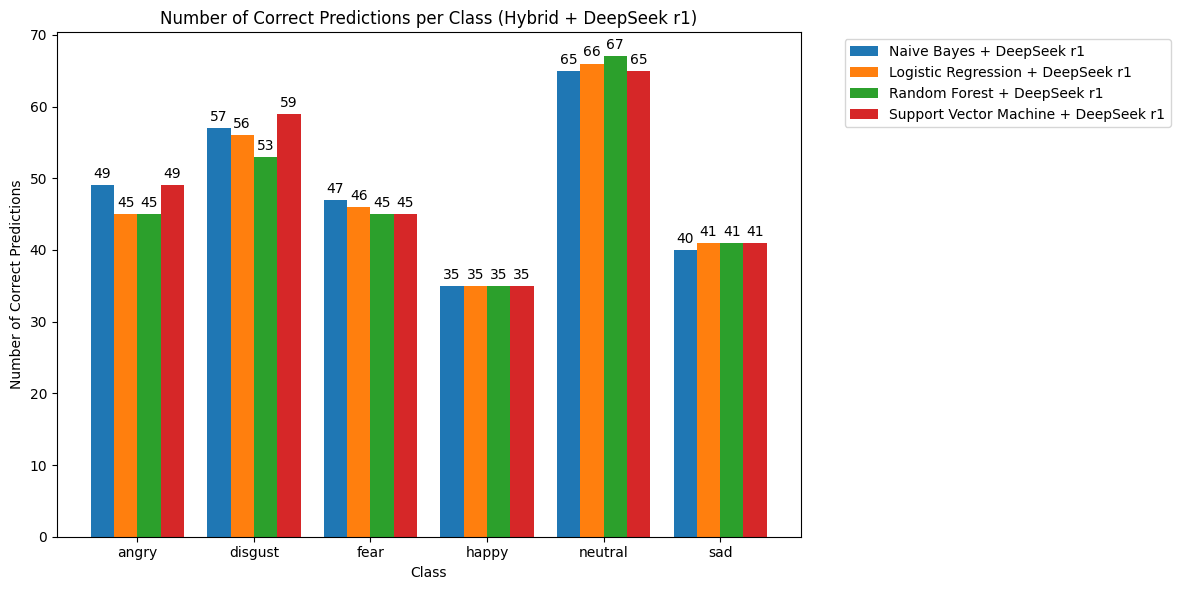

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define the path to the output predictions CSV file (update this path as needed)
OUTPUT_PRED_FILE = "../data/processed/hybrid_DeepSeek_predictions.csv"

true_col = "label"

model_pred_cols = {
    "Naive Bayes + DeepSeek r1": "naive_bayes_deepseek_pred",
    "Logistic Regression + DeepSeek r1": "logistic_regression_deepseek_pred",
    "Random Forest + DeepSeek r1": "random_forest_deepseek_pred",
    "Support Vector Machine + DeepSeek r1": "support_vector_machine_deepseek_pred"
}

labels = ["angry", "disgust", "fear", "happy", "neutral", "sad"]

def count_correct_per_class(df, true_col, pred_col, labels):
    counts = []
    for label in labels:
        correct_count = ((df[true_col] == label) & (df[pred_col] == label)).sum()
        counts.append(correct_count)
    return counts

# Read the CSV file once
result_df = pd.read_csv(OUTPUT_PRED_FILE)

# Compute counts for all models
all_counts = {}
for model_name, pred_col in model_pred_cols.items():
    all_counts[model_name] = count_correct_per_class(result_df, true_col, pred_col, labels)

# Plot the bar chart
x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - 1.5*width, all_counts["Naive Bayes + DeepSeek r1"], width, label="Naive Bayes + DeepSeek r1")
bars2 = ax.bar(x - 0.5*width, all_counts["Logistic Regression + DeepSeek r1"], width, label="Logistic Regression + DeepSeek r1")
bars3 = ax.bar(x + 0.5*width, all_counts["Random Forest + DeepSeek r1"], width, label="Random Forest + DeepSeek r1")
bars4 = ax.bar(x + 1.5*width, all_counts["Support Vector Machine + DeepSeek r1"], width, label="Support Vector Machine + DeepSeek r1")

ax.set_xlabel("Class")
ax.set_ylabel("Number of Correct Predictions")
ax.set_title("Number of Correct Predictions per Class (Hybrid + DeepSeek r1)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)
ax.bar_label(bars3, padding=3)
ax.bar_label(bars4, padding=3)

plt.tight_layout()
plt.show()

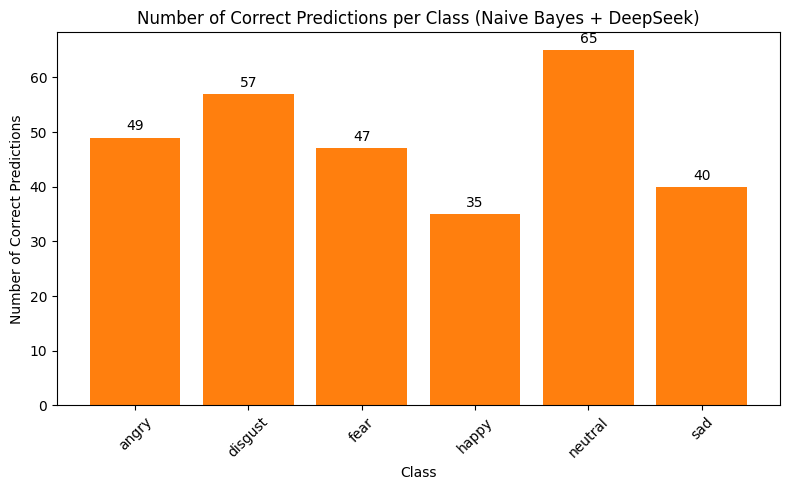

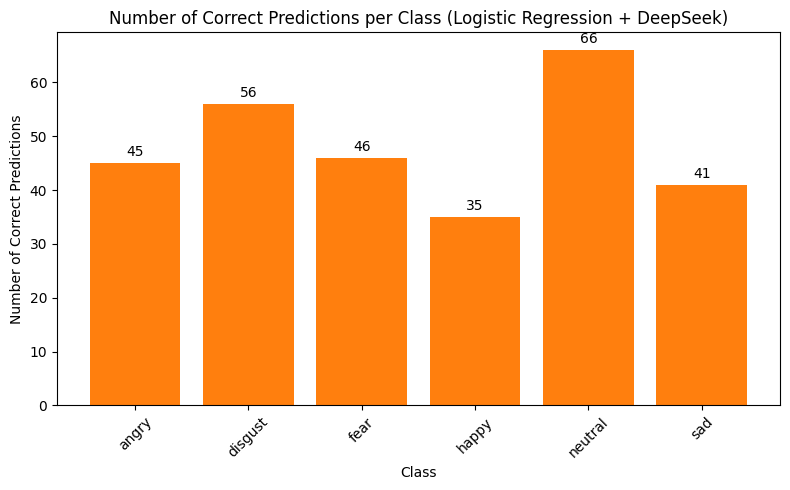

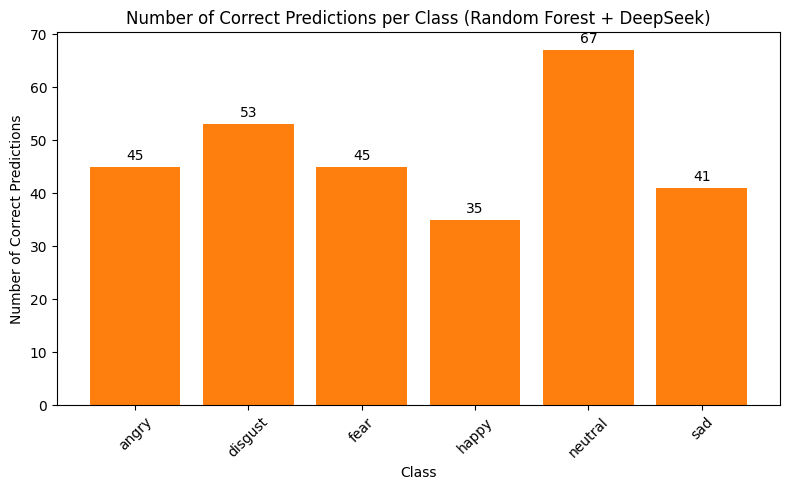

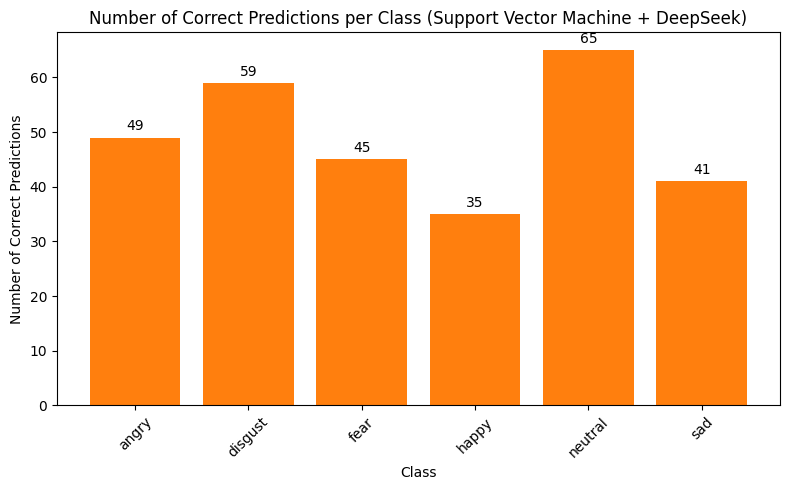

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# ใช้ result_df ที่มีอยู่แล้ว
true_col = "label"

labels = ["angry", "disgust", "fear", "happy", "neutral", "sad"]

model_pred_cols = {
    "Naive Bayes + DeepSeek": "naive_bayes_deepseek_pred",
    "Logistic Regression + DeepSeek": "logistic_regression_deepseek_pred",
    "Random Forest + DeepSeek": "random_forest_deepseek_pred",
    "Support Vector Machine + DeepSeek": "support_vector_machine_deepseek_pred"
}

for model_name, pred_col in model_pred_cols.items():
    if pred_col not in result_df.columns:
        print(f"ไม่พบคอลัมน์ {pred_col}")
        continue

    y_true = result_df[true_col]
    y_pred = result_df[pred_col]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    correct_counts = np.diag(cm)

    plt.figure(figsize=(8, 5))
    plt.bar(labels, correct_counts)
    plt.title(f"Number of Correct Predictions per Class ({model_name})")
    plt.xlabel("Class")
    plt.bar_label(plt.bar(labels, correct_counts), padding=3)
    plt.ylabel("Number of Correct Predictions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

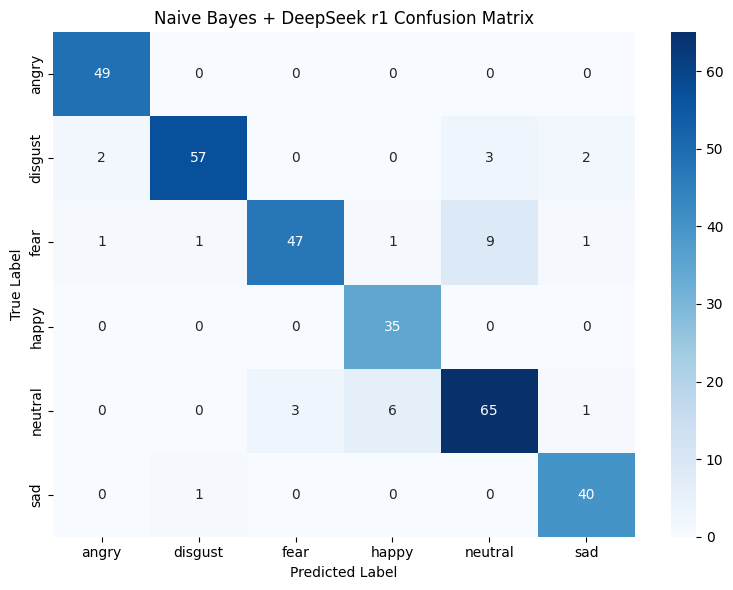

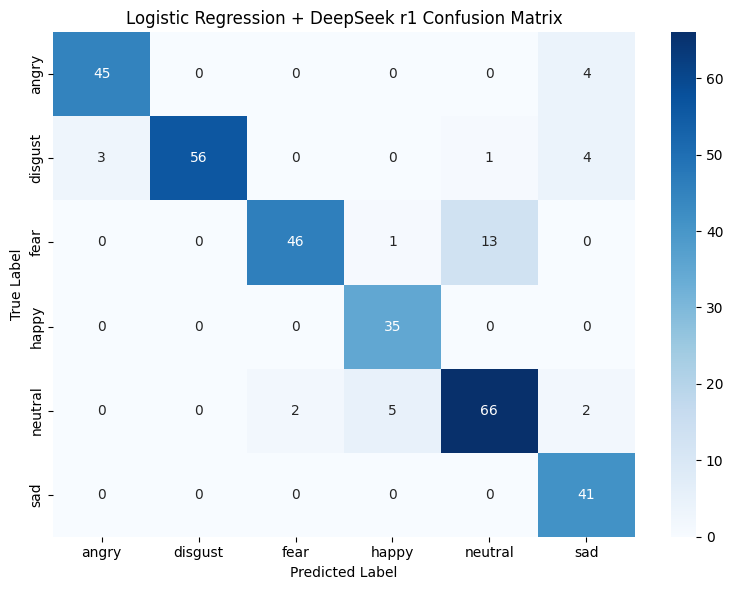

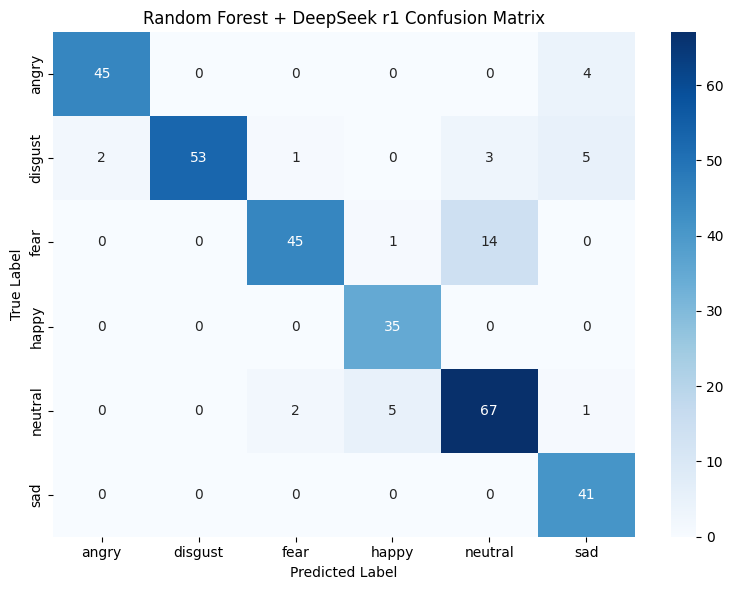

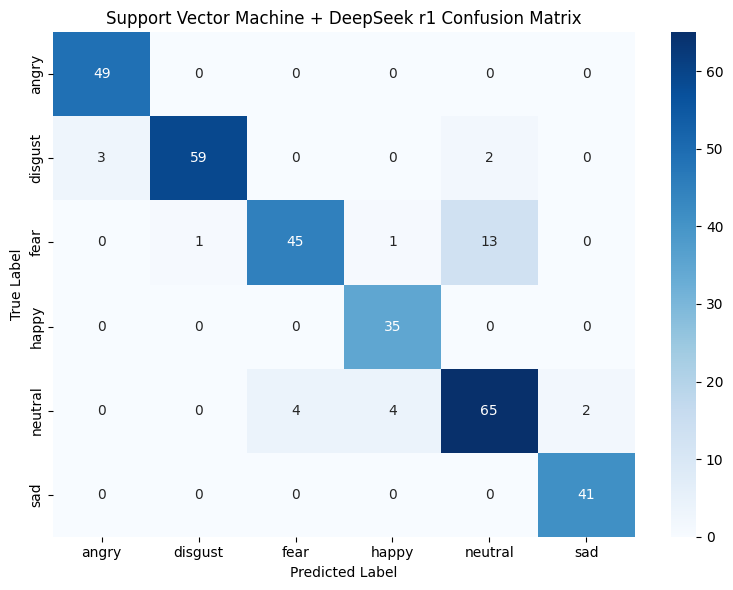

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

OUTPUT_PRED_FILE = "../data/processed/hybrid_DeepSeek_predictions.csv"

result_df = pd.read_csv(OUTPUT_PRED_FILE)

true_col = "label"

labels = ["angry", "disgust", "fear", "happy", "neutral", "sad"]

model_pred_cols = {
    "Naive Bayes + DeepSeek r1": "naive_bayes_deepseek_pred",
    "Logistic Regression + DeepSeek r1": "logistic_regression_deepseek_pred",
    "Random Forest + DeepSeek r1": "random_forest_deepseek_pred",
    "Support Vector Machine + DeepSeek r1": "support_vector_machine_deepseek_pred"
}

def plot_confusion_matrix_for_model(df, true_col, pred_col, labels, model_name):
    cm = confusion_matrix(df[true_col], df[pred_col], labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

for model_name, pred_col in model_pred_cols.items():
    if pred_col in result_df.columns:
        plot_confusion_matrix_for_model(
            result_df,
            true_col,
            pred_col,
            labels,
            model_name
        )
    else:
        print(f"ไม่พบคอลัมน์: {pred_col}")

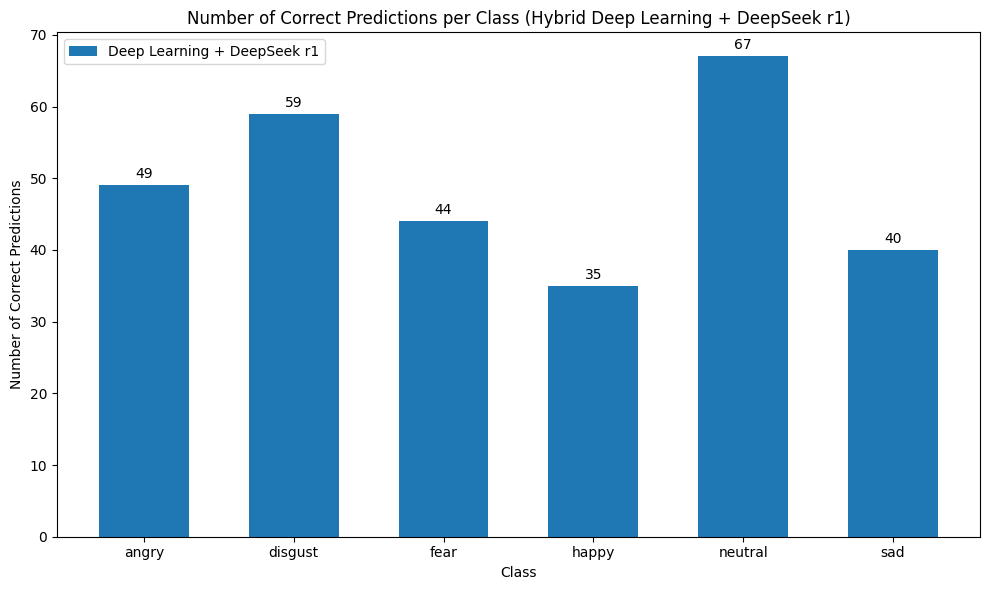

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# OUTPUT_PRED_FILE = "../data/processed/hybrid_DeepSeek_predictions.csv"

true_col = "label"
pred_col = "dl_deepseek_pred"

labels = ["angry", "disgust", "fear", "happy", "neutral", "sad"]

def count_correct_per_class(df, true_col, pred_col, labels):
    counts = []
    for label in labels:
        correct_count = ((df[true_col] == label) & (df[pred_col] == label)).sum()
        counts.append(correct_count)
    return counts

result_df = pd.read_csv("../data/processed/hybrid_DeepSeek_predictions.csv")
counts = count_correct_per_class(result_df, true_col, pred_col, labels)

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(x, counts, width=0.6, label="Deep Learning + DeepSeek r1")

ax.set_xlabel("Class")
ax.set_ylabel("Number of Correct Predictions")
ax.set_title("Number of Correct Predictions per Class (Hybrid Deep Learning + DeepSeek r1)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()


Deep Learning + DeepSeek r1 Confusion Matrix


,angry,disgust,fear,happy,neutral,sad
angry,49,0,0,0,0,0
disgust,1,59,3,0,0,1
fear,0,2,44,2,12,0
happy,0,0,0,35,0,0
neutral,0,1,2,3,67,2
sad,0,0,1,0,0,40


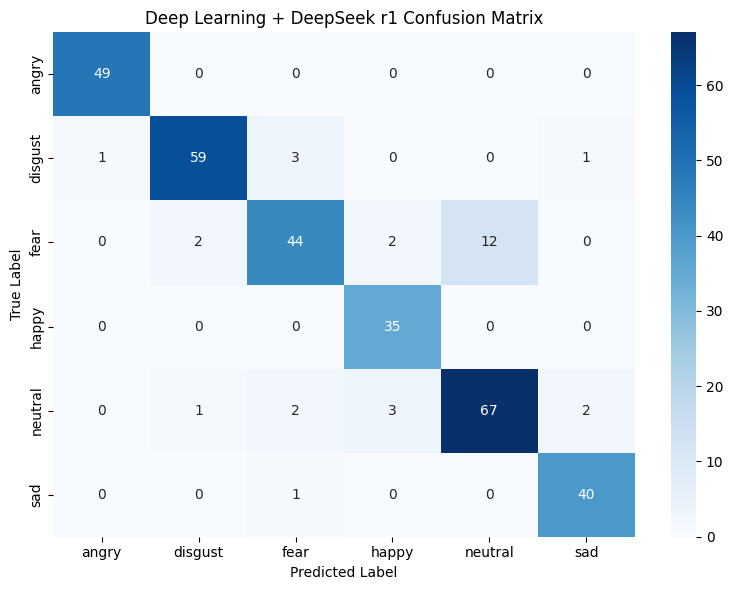

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


OUTPUT_PRED_FILE = "../data/processed/hybrid_DeepSeek_predictions.csv"

result_df = pd.read_csv(OUTPUT_PRED_FILE)

true_col = "label"
pred_col = "dl_deepseek_pred"

labels = ["angry", "disgust", "fear", "happy", "neutral", "sad"]

# ตรวจว่ามี column จริงไหม
if pred_col not in result_df.columns:
    print(f"ไม่พบคอลัมน์: {pred_col}")
else:
    # สร้าง confusion matrix
    cm = confusion_matrix(
        result_df[true_col],
        result_df[pred_col],
        labels=labels
    )

    # แปลงเป็นตาราง
    cm_df = pd.DataFrame(
        cm,
        index=labels,
        columns=labels
    )

    print("\n" + "=" * 60)
    print("Deep Learning + DeepSeek r1 Confusion Matrix")
    print("=" * 60)
    display(cm_df)

    # วาด heatmap แบบในรูป
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title("Deep Learning + DeepSeek r1 Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()